# Super-Resolution DDPM on STAR

Trains and samples the DeepLense `SuperResolutionDDPM` on real HR/LR patch pairs from the STAR benchmark (PLAN.md item C4): [KUOCHENG/STAR](https://huggingface.co/datasets/KUOCHENG/STAR), with 500 training and 100 held-out evaluation pairs from Hubble Space Telescope observations. Data are downloaded on first run into `./data/star` (a common, gitignored cache, safe to delete).

## Normalization

Each patch is normalized by its own valid-pixel statistics, following STAR (`libs/dataset.py:64-80`), which uses the mask to exclude padding. Pixels are sky-subtracted, scaled by a MAD noise estimate, `asinh`-compressed, and mapped to `[-1, 1]`.

- **`asinh`, not a bare min-max.** Astronomical patches carry a wide dynamic range, and a linear rescale leaves HR pixels at std ≈ 0.03. The reverse process injects `sqrt(beta_t)` ≈ 0.010 of noise per step, accumulating to ≈ 0.047 over the last 20 steps alone, so a linear mapping puts the whole signal under the sampler's own noise. `asinh` brings pixel std to ≈ 0.28.
- **True min/max endpoints, no percentile clip.** `asinh` already compresses the bright end. Clipping on top of it discards the bright sources, which are both the astronomical signal and what STAR's `max - min` data range measures. The transform stays bijective, so `to_star_space` can invert it exactly for evaluation.
- **`[-1, 1]`, not `[0, 1]`.** This is diffusers' model space. The DeepLense CGDPM source works in `[0, 1]` and ends sampling with a batch-wide min-max rescale; `CGDPM` does neither, returning model space and leaving display conversion to the caller.

LR and HR each use their own statistics. In STAR they sit on different photometric scales (LR sky is offset by +0.143 and its noise is 1.43x HR's, consistently across patches), so this removes a real instrument difference.

Restart the kernel before rerunning after changing library source.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import snapshot_download
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().parent))  # repo root, for `import astrogen` from examples/
from astrogen.tasks import SuperResolutionDDPM

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

Could not find the bitsandbytes CUDA binary at PosixPath('/home/mi3se/.conda/envs/astroclip/lib/python3.10/site-packages/bitsandbytes/libbitsandbytes_cuda128.so')
The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.


## Data

![STAR dataset examples](../assets/star-dataset.png)

*STAR extends prior single-galaxy crops (a) to full field-level patches spanning individual galaxies, interacting pairs, weak-lensing arcs, and dark-matter halos (b), the source of the HR/LR pairs trained on below. Image: [STAR](https://github.com/GuoCheng12/STAR).*

In [ ]:
DATA_DIR = Path.cwd().parent / "data" / "star"
try:
    snapshot_download(
        repo_id="KUOCHENG/STAR",
        repo_type="dataset",
        allow_patterns="sampled_data/x2/*",
        local_dir=DATA_DIR,
        max_workers=4,
    )
except Exception as error:
    print(f"download incomplete ({error}); using existing cache in {DATA_DIR}")
root = DATA_DIR / "sampled_data" / "x2"

Fetching 1202 files:   0%|          | 0/1202 [00:00<?, ?it/s]

### Normalization

The transforms described above: `_stretch` maps a patch into the `[-1, 1]` model space, and `to_star_space` inverts it into the space STAR scores in.

In [3]:
MASK_FILL = -1.0  # masked padding sits at the floor of the [-1, 1] model space


def _read_image(path: Path) -> tuple[np.ndarray, np.ndarray]:
    data = np.load(path, allow_pickle=True).item()
    image = data["image"].astype(np.float32)
    valid = data["mask"].astype(bool) & np.isfinite(image)
    return image, valid


def _star_normalize(image: np.ndarray, valid: np.ndarray) -> np.ndarray:
    """STAR's per-patch min-max on valid pixels (`libs/dataset.py:64-80`)."""
    pixels = image[valid]
    minimum, maximum = float(pixels.min()), float(pixels.max())
    normalized = (image - minimum) / (maximum - minimum + 1e-8)
    normalized[~valid] = 0.0
    return normalized

In [4]:
def _stretch(path: Path) -> tuple[torch.Tensor, dict[str, float]]:
    """Sky-subtract, scale by the noise level, `asinh`-compress, map to [-1, 1]."""
    image, valid = _read_image(path)
    pixels = image[valid]
    sky = float(np.median(pixels))
    # 1.4826 * MAD is the Gaussian-consistent robust estimate of the noise sigma.
    noise = float(np.median(np.abs(pixels - sky)) * 1.4826) or 1.0
    compressed = np.arcsinh((image - sky) / noise)
    low, high = float(compressed[valid].min()), float(compressed[valid].max())
    normalized = (compressed - low) / (high - low + 1e-8) * 2 - 1
    normalized[~valid] = MASK_FILL
    statistics = {"sky": sky, "noise": noise, "low": low, "high": high}
    return torch.from_numpy(normalized.astype(np.float32)).unsqueeze(0), statistics


def to_star_space(
    normalized: torch.Tensor, statistics: dict[str, float], valid: np.ndarray
) -> np.ndarray:
    """Invert `_stretch`, then apply the normalization STAR scores in."""
    scaled = (normalized + 1) / 2 * (statistics["high"] - statistics["low"]) + statistics["low"]
    physical = (torch.sinh(scaled) * statistics["noise"] + statistics["sky"]).numpy()
    return _star_normalize(physical, valid)

### Dataset

In [5]:
class STARPatchDataset(Dataset):
    """HR/LR patch pairs from one or more STAR sampled_data/x2 splits."""

    def __init__(self, root: Path, splits: list[str]) -> None:
        self.items: list[tuple[Path, Path]] = []
        for split in splits:
            hr_dir, lr_dir = root / f"{split}_hr_patch", root / f"{split}_lr_patch"
            hr_names = {p.name for p in hr_dir.glob("*.npy")}
            lr_names = {p.name.replace("_hr_lr_patch_", "_hr_hr_patch_") for p in lr_dir.glob("*.npy")}
            # Tolerate a partial local cache (e.g. an interrupted download) by
            # only pairing names present on both sides.
            for name in sorted(hr_names & lr_names):
                self.items.append((hr_dir / name, lr_dir / name.replace("_hr_hr_patch_", "_hr_lr_patch_")))

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        hr_path, lr_path = self.items[index]
        return _stretch(lr_path)[0], _stretch(hr_path)[0]

    def reference(self, index: int) -> dict:
        """Everything needed to score and show a prediction for `index`.

        ``input`` and ``target`` are the real LR and HR patches in STAR's
        space, at their own native sizes.
        """
        hr_path, lr_path = self.items[index]
        high_image, valid = _read_image(hr_path)
        low_image, low_valid = _read_image(lr_path)
        return {
            "input": _star_normalize(low_image, low_valid),
            "target": _star_normalize(high_image, valid),
            "valid": valid,
            "low_statistics": _stretch(lr_path)[1],
            "high_statistics": _stretch(hr_path)[1],
        }

In [6]:
train_dataset = STARPatchDataset(root, ["train"])
eval_dataset = STARPatchDataset(root, ["eval"])
batch_size = 4
num_workers = 4

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, 
    num_workers=num_workers, persistent_workers=True
)
eval_loader = DataLoader(
    eval_dataset, batch_size=batch_size, shuffle=False, 
    num_workers=num_workers, persistent_workers=True
)

_, high_sample = next(iter(train_loader))
print(f"{len(train_dataset)} train / {len(eval_dataset)} eval pairs")
print(f"HR normalized: mean={high_sample.mean():.3f} std={high_sample.std():.3f} "
      f"range=[{high_sample.min():.2f}, {high_sample.max():.2f}]")
# A linear rescale of this data leaves std ~0.03, under the sampler's own
# per-step noise, and sampling then cannot produce anything but noise.
assert high_sample.std() > 0.15, (
    f"HR std {high_sample.std():.3f} is near the sampler's per-step noise floor; "
    "sampling cannot succeed at this contrast"
)

500 train / 100 eval pairs
HR normalized: mean=-0.369 std=0.253 range=[-1.00, 1.00]


## Training

In [7]:
model = SuperResolutionDDPM(prediction_type="v_prediction").to(DEVICE)
checkpoint_path = DATA_DIR / "cgdpm_star_best.pt"


def train(optimizer: torch.optim.Optimizer, epochs: int) -> list[float]:
    """Train for one optimization run from the DeepLense reference."""
    model.train()
    run_losses: list[float] = []
    best_loss = float("inf")
    learning_rate = optimizer.param_groups[0]["lr"]
    progress = tqdm(range(epochs), desc=f"Adam lr={learning_rate:g}")
    for epoch in progress:
        epoch_losses = []
        batches = tqdm(train_loader, desc=f"epoch {epoch + 1}/{epochs}", leave=False)
        for low_resolution, high_resolution in batches:
            optimizer.zero_grad()
            loss = model(low_resolution.to(DEVICE), high_resolution.to(DEVICE))
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
            batches.set_postfix(loss=f"{loss.item():.4f}")
        run_losses.extend(epoch_losses)
        mean_loss = sum(epoch_losses) / len(epoch_losses)
        progress.set_postfix(mean_loss=f"{mean_loss:.4f}")
        if mean_loss < best_loss:
            best_loss = mean_loss
            torch.save(model.state_dict(), checkpoint_path)
    return run_losses

In [ ]:
# The reference starts a fresh Adam optimizer for each training call. EPOCHS is
# reduced from the reference's 100 to keep this example runnable; raise it for
# a real run.
EPOCHS = 100

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
losses = train(optimizer, epochs=EPOCHS)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
losses.extend(train(optimizer, epochs=EPOCHS))
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE, weights_only=True))

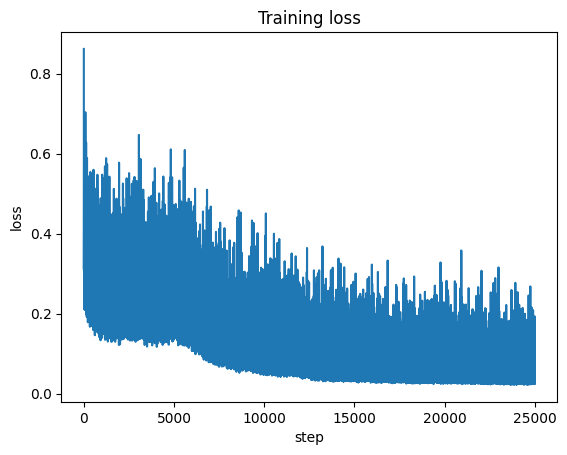

In [9]:
plt.plot(losses)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Training loss")
plt.show()

## Evaluation

Scoring is in STAR's space: `evaluate_metric_SR` (`libs/utils.py:314-350`) computes masked PSNR/SSIM on per-patch min-max `[0, 1]` tensors, with `data_range` from the target's valid range. `to_star_space` inverts this notebook's `asinh` stretch and applies that normalization, so the numbers are comparable to STAR's published table.

In [10]:
def score(prediction: np.ndarray, target: np.ndarray, valid: np.ndarray) -> tuple[float, float]:
    """Masked PSNR/SSIM in STAR's space, following `evaluate_metric_SR`."""
    minimum, maximum = target[valid].min(), target[valid].max()
    data_range = float(maximum - minimum)
    # STAR clips the prediction into the target's valid range before scoring.
    prediction = np.clip(prediction, minimum, maximum)
    return (
        psnr(target[valid], prediction[valid], data_range=data_range),
        ssim(target[valid], prediction[valid], data_range=data_range),
    )

In [ ]:
VISUALIZE_COUNT = 4
scores: dict[str, list[tuple[float, float]]] = {"sample": [], "bilinear": []}
panels: list[tuple[np.ndarray, ...]] = []
row_index = 0
for low_resolution, high_resolution in tqdm(eval_loader, desc="scoring eval set"):
    samples = model.sample(low_resolution.to(DEVICE), image_size=high_resolution.shape[-1]).cpu()
    baseline = torch.nn.functional.interpolate(
        low_resolution, size=high_resolution.shape[-2:], mode="bilinear", align_corners=False
    )
    for offset in range(low_resolution.shape[0]):
        reference = eval_dataset.reference(row_index)
        target, valid = reference["target"], reference["valid"]
        predictions = {
            name: to_star_space(tensor, statistics, valid)
            for name, tensor, statistics in (
                ("sample", samples[offset, 0], reference["high_statistics"]),
                ("bilinear", baseline[offset, 0], reference["low_statistics"]),
            )
        }
        for name, prediction in predictions.items():
            scores[name].append(score(prediction, target, valid))
        if row_index < VISUALIZE_COUNT:
            panels.append((reference["input"], predictions["bilinear"], predictions["sample"], target))
        row_index += 1

for name, values in scores.items():
    print(f"{name:<9} PSNR={np.mean([v[0] for v in values]):.2f} dB  "
          f"SSIM={np.mean([v[1] for v in values]):.4f}  ({len(values)} eval pairs)")

### Visualization

Each row shows the held-out low-resolution input at its native size, its bilinear upsample, the `SuperResolutionDDPM` output, and the real high-resolution target.

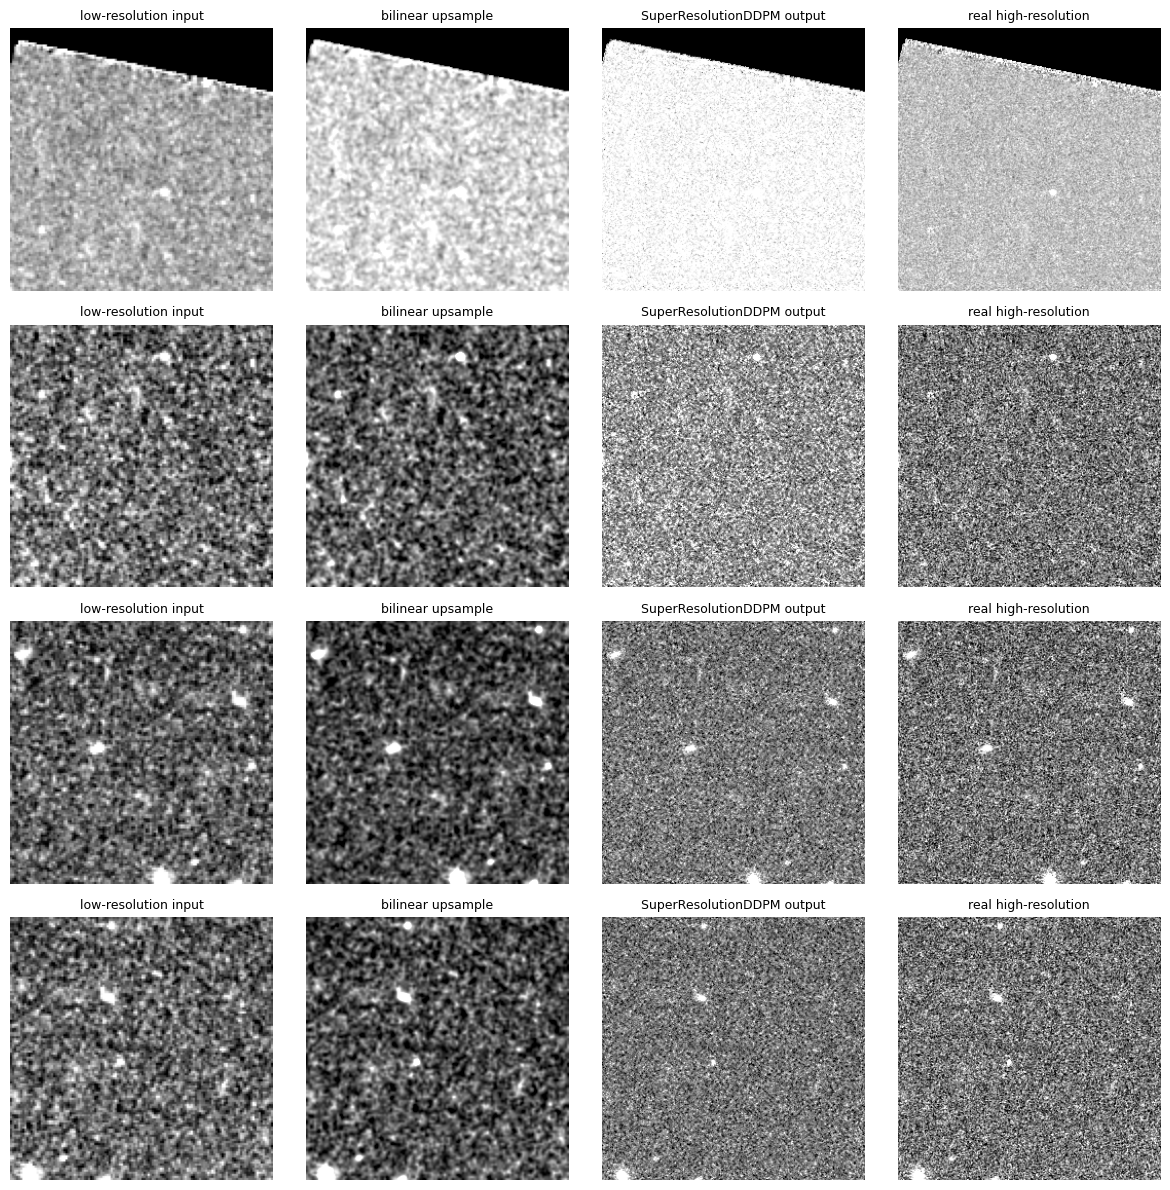

In [12]:
TITLES = [
    "low-resolution input",
    "bilinear upsample",
    "SuperResolutionDDPM output",
    "real high-resolution",
]


def show(panels: list[tuple[np.ndarray, ...]]) -> None:
    """One row per patch, two display scales, see below."""
    _, axes = plt.subplots(len(panels), 4, figsize=(12, 3 * len(panels)))
    for row, images in enumerate(panels):
        # The input and its bilinear upsample are min-max normalized by the LR
        # patch's own range, the output and target by the HR patch's. Those
        # ranges differ, so a single scale washes one pair out. Within each pair
        # the scale is shared, which is what matters: a failed sample cannot be
        # rescaled into looking like the target.
        scales = (np.percentile(images[0], [1, 99]), np.percentile(images[-1], [1, 99]))
        for col, (image, title) in enumerate(zip(images, TITLES)):
            vmin, vmax = scales[0] if col < 2 else scales[1]
            ax = axes[row, col]
            ax.imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
            ax.set_title(title, fontsize=9)
            ax.axis("off")
    plt.tight_layout()
    plt.show()


show(panels)